# TENNIS ACE

## PROJECT GOALS

<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>Create a linear regression model that predicts the outcome for a tennis player based on their playing habits.</li>
    <li>By analyzing and modeling the Association of Tennis Professionals (ATP) data, determine what it takes to be one of the best tennis players in the world.</li>
</ul>
</div>

## DATA DESCRIPTION

<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>Data from the top 1,500 ranked players in the ATP over the span of 2009 to 2017 are provided in file.</li>
    <li>The statistics recorded for each player in each year include service game (offensive) statistics, return game (defensive) statistics and outcomes.</li>
</ul>
</div>

<div style="background-color:#fff8e1; padding:10px;">
<table style="background-color: #f0fff0; border-collapse: collapse;"
    <tr><th>Feature</th><th>Description</th></tr>
    <tr><td>Player</td><td>Name of the tennis player</td></tr>
    <tr><td>Year</td><td>Year data was recorded</td></tr>
    <tr><td>Aces</td><td>Number of serves by the player where the receiver does not touch the ball</td></tr>
    <tr><td>DoubleFaults</td><td>Number of times player missed both first and second serve attempts.</td></tr>
    <tr><td>FirstServe</td><td>% of first-serve attempts made</td></tr>
    <tr><td>FirstServePointsWon</td><td>% of first-serve attempt points won by the plyaer</td></tr>
    <tr><td>SecondServePointsWon</td><td>% of second-serve attempt points won by the player</td></tr>
    <tr><td>BreakPointsFaced</td><td>Number of times where the receiver could have won service game of the player</td></tr>
    <tr><td>BreakPointsSaved</td><td>% of the time the player was able to stop the receiver from winning service game when they had the chance</td></tr>
    <tr><td>ServiceGamesPlayed</td><td>Total number of games where the player served</td></tr>
    <tr><td>ServiceGamesWon</td><td>Total number of games where the player served and won</td></tr>
    <tr><td>TotalServicePointsWon</td><td>% of points in games where the player served that they won</td></tr>
    <tr><td>FirstServeReturnPointsWon</td><td>% of opponents first-serve points the player was able to win</td></tr>
    <tr><td>SecondServeReturnPointsWon</td><td>% of opponents second-serve points the player was able to win</td></tr>
    <tr><td>BreakPointsOpportunities</td><td>Number of times where the player could have won the service game of the opponent</td></tr>
    <tr><td>BreakPointsConverted</td><td>% of the time the player was able to win their opponent's service game when they had the chance</td></tr>
    <tr><td>ReturnGamesPlayed</td><td>Total number of games where the player's opponent served</td></tr>
    <tr><td>ReturnGamesWon</td><td>Total number of games where the player's opponent served and player won</td></tr>
    <tr><td>ReturnPointsWon</td><td>Total number of points where the player's opponent served and the player won</td></tr>
    <tr><td>TotalPointsWon</td><td>% of points won by the player</td></tr>
    <tr><td>Wins</td><td>Number of matches won in a year</td></tr>
    <tr><td>Losses</td><td>Number of matches lost in a year</td></tr>
    <tr><td>Winnings</td><td>Total winnings in USD($) in a year</td></tr>
    <tr><td>Ranking</td><td>Ranking at the end of year</td></tr>
</div>

In [91]:
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [92]:
# Load and inspect DataFrame
df = pd.read_csv('tennis_stats.csv')
df.head()

,Player,Year,FirstServe,FirstServePointsWon,FirstServeReturnPointsWon,SecondServePointsWon,SecondServeReturnPointsWon,Aces,BreakPointsConverted,BreakPointsFaced,...,ReturnGamesWon,ReturnPointsWon,ServiceGamesPlayed,ServiceGamesWon,TotalPointsWon,TotalServicePointsWon,Wins,Losses,Winnings,Ranking
0,Pedro Sousa,2016,0.88,0.50,0.38,0.50,0.39,0,0.14,7,...,0.11,0.38,8,0.50,0.43,0.50,1,2,39820,119
1,Roman Safiullin,2017,0.84,0.62,0.26,0.33,0.07,7,0.00,7,...,0.00,0.20,9,0.67,0.41,0.57,0,1,17334,381
2,Pedro Sousa,2017,0.83,0.60,0.28,0.53,0.44,2,0.38,10,...,0.16,0.34,17,0.65,0.45,0.59,4,1,109827,119
3,Rogerio Dutra Silva,2010,0.83,0.64,0.34,0.59,0.33,2,0.33,5,...,0.14,0.34,15,0.80,0.49,0.63,0,0,9761,125
4,Daniel Gimeno-Traver,2017,0.81,0.54,0.00,0.33,0.33,1,0.00,2,...,0.00,0.20,2,0.50,0.35,0.50,0,1,32879,272


### Data Wrangling

<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>There are two duplicates in the DataFrame, and it has been dropped.</li>
    <li>No missing values.</li>
    <li>Data types are in numerical.</li>
</ul>
</div>

In [93]:
# Check for duplicates
df.duplicated().sum()

np.int64(2)

In [94]:
# Rows with duplicate
df[df.duplicated(keep=False)]

,Player,Year,FirstServe,FirstServePointsWon,FirstServeReturnPointsWon,SecondServePointsWon,SecondServeReturnPointsWon,Aces,BreakPointsConverted,BreakPointsFaced,...,ReturnGamesWon,ReturnPointsWon,ServiceGamesPlayed,ServiceGamesWon,TotalPointsWon,TotalServicePointsWon,Wins,Losses,Winnings,Ranking
935,Facundo Bagnis,2015,0.59,0.64,0.30,0.52,0.45,20,0.43,43,...,0.16,0.35,63,0.68,0.47,0.59,2,4,123931,223
938,Facundo Bagnis,2015,0.59,0.64,0.30,0.52,0.45,20,0.43,43,...,0.16,0.35,63,0.68,0.47,0.59,2,4,123931,223
1315,Andrea Arnaboldi,2015,0.57,0.68,0.22,0.50,0.46,23,0.30,52,...,0.13,0.32,64,0.73,0.47,0.60,1,3,154062,222
1317,Andrea Arnaboldi,2015,0.57,0.68,0.22,0.50,0.46,23,0.30,52,...,0.13,0.32,64,0.73,0.47,0.60,1,3,154062,222


In [95]:
# Drop duplicates
df = df.drop_duplicates()

# Double check on duplicates
# df.duplicated().sum()

In [96]:
# Check for missing values
df.isnull().sum()

Player                        0
Year                          0
FirstServe                    0
FirstServePointsWon           0
FirstServeReturnPointsWon     0
SecondServePointsWon          0
SecondServeReturnPointsWon    0
Aces                          0
BreakPointsConverted          0
BreakPointsFaced              0
BreakPointsOpportunities      0
BreakPointsSaved              0
DoubleFaults                  0
ReturnGamesPlayed             0
ReturnGamesWon                0
ReturnPointsWon               0
ServiceGamesPlayed            0
ServiceGamesWon               0
TotalPointsWon                0
TotalServicePointsWon         0
Wins                          0
Losses                        0
Winnings                      0
Ranking                       0
dtype: int64

In [97]:
# Check for data types
df.dtypes

Player                            str
Year                            int64
FirstServe                    float64
FirstServePointsWon           float64
FirstServeReturnPointsWon     float64
SecondServePointsWon          float64
SecondServeReturnPointsWon    float64
Aces                            int64
BreakPointsConverted          float64
BreakPointsFaced                int64
BreakPointsOpportunities        int64
BreakPointsSaved              float64
DoubleFaults                    int64
ReturnGamesPlayed               int64
ReturnGamesWon                float64
ReturnPointsWon               float64
ServiceGamesPlayed              int64
ServiceGamesWon               float64
TotalPointsWon                float64
TotalServicePointsWon         float64
Wins                            int64
Losses                          int64
Winnings                        int64
Ranking                         int64
dtype: object

## EXPLORATORY DATA ANALYSIS

<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>Since this is just to quickly explore the relationship between features and outcomes for building regression model, univariate analysis is skipped.</li>
    <li>The outcome that I'm focusing is 'Winnings'.</li>
</ul>
</div>

### Bivariate Analysis

In [98]:
features = [
    'FirstServe', 
    'FirstServePointsWon', 
    'FirstServeReturnPointsWon', 
    'SecondServePointsWon', 
    'SecondServeReturnPointsWon', 
    'Aces', 
    'BreakPointsConverted', 
    'BreakPointsFaced', 
    'BreakPointsOpportunities', 
    'BreakPointsSaved', 
    'DoubleFaults', 
    'ReturnGamesPlayed',
    'ReturnGamesWon',
    'ReturnPointsWon',
    'ServiceGamesPlayed',
    'ServiceGamesWon',               
    'TotalPointsWon',
    'TotalServicePointsWon'
]
outcome = ['Winnings']

<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>Based on the scatter plots, these are few features that have linear positive trend that affect 'Winnings'. There are:</li>
    <ul>
        <li>Aces</li>
        <li>BreakPointsFaced</li>
        <li>BreakPointsOpportunities</li>
        <li>DoubleFaults</li>
        <li>ReturnGamesPlayed</li>
        <li>ServiceGamesPlayed</li>
    </ul>
</ul>
</div>

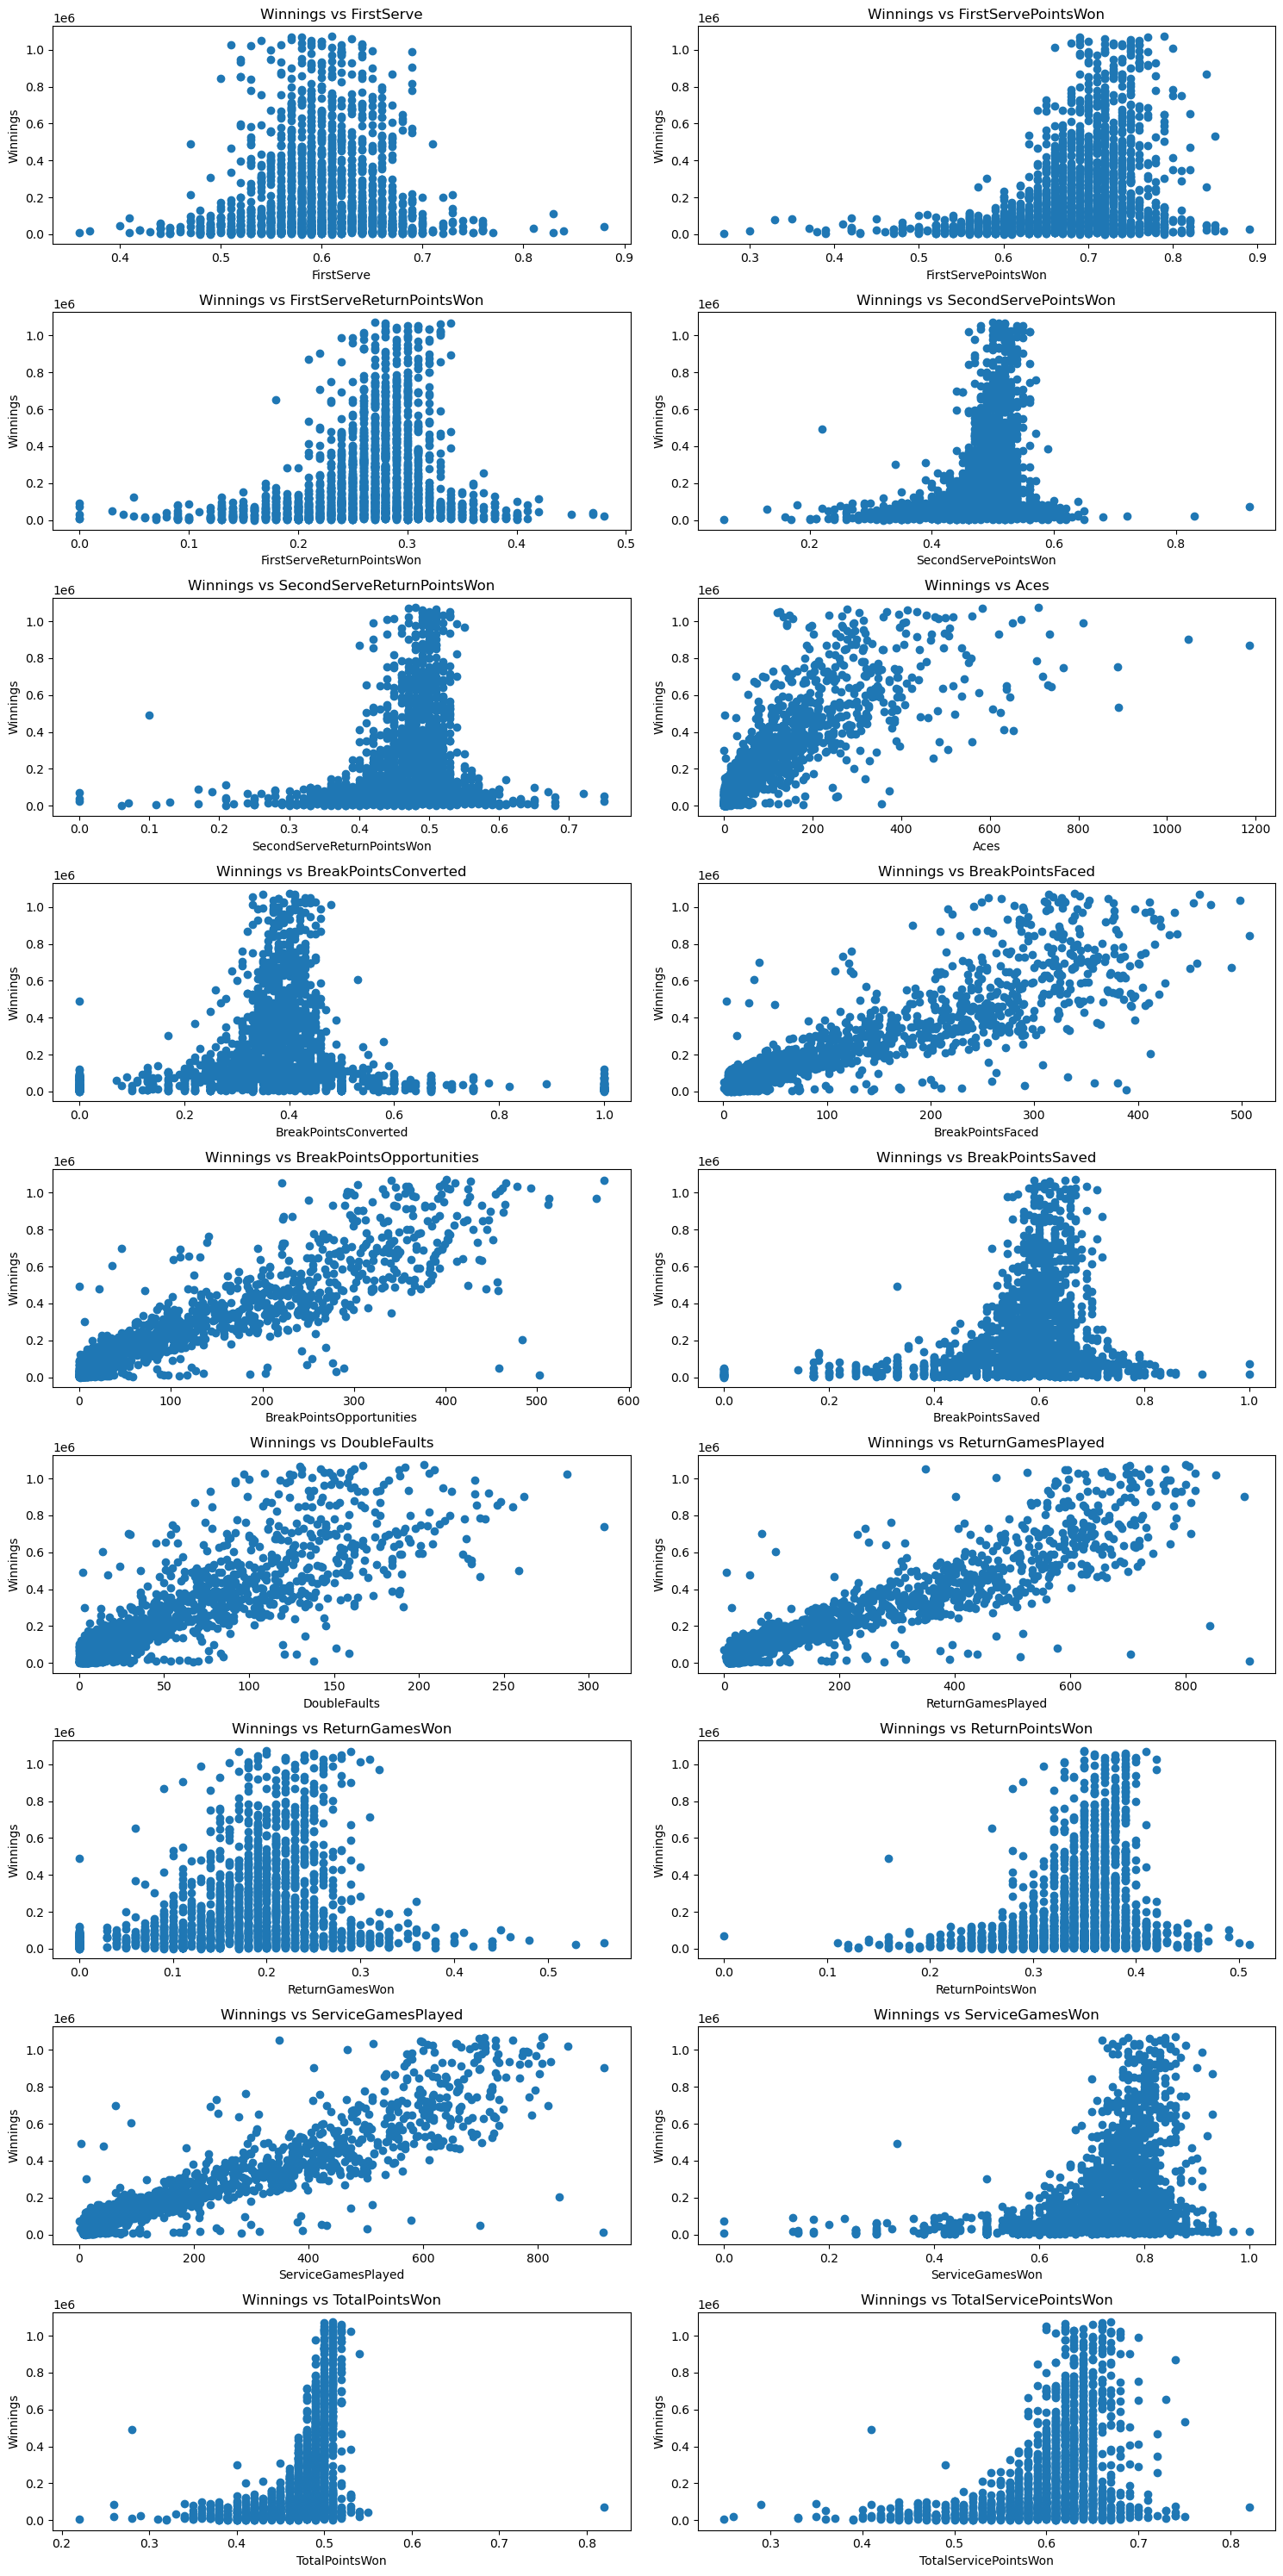

In [99]:
plt.figure(figsize=(15,30))
for i in enumerate(features):
    plt.subplot(9, 2, i[0]+1)
    plt.scatter(x=i[1], y='Winnings', data=df)
    plt.xlabel(f"{i[1]}")
    plt.ylabel('Winnings')
    plt.title(f"Winnings vs {i[1]}")
plt.tight_layout()
plt.show()
plt.close()

## Modeling

<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>'random_state' will be set constant at 66 to make sure results are consistent and reproducible. Any integer would do, as long as it is constant for every split.</li>
    <li>By looking at the highest test_score (R² values on test set): '
    <ol>
        <li>ServiceGamesPlayed'</li>
        <li>'ReturnGamesPlayed'</li>
        <li>'BreakPointsOpportunities'</li>
</ul>
</div>


    Train Score of Aces: 0.6349
    Test Score of Aces: 0.6467
    
------------------------------------------------------------

    Train Score of BreakPointsFaced: 0.7685
    Test Score of BreakPointsFaced: 0.7626
    
------------------------------------------------------------

    Train Score of BreakPointsOpportunities: 0.8127
    Test Score of BreakPointsOpportunities: 0.8031
    
------------------------------------------------------------

    Train Score of DoubleFaults: 0.7334
    Test Score of DoubleFaults: 0.7185
    
------------------------------------------------------------

    Train Score of ReturnGamesPlayed: 0.8331
    Test Score of ReturnGamesPlayed: 0.8317
    
------------------------------------------------------------

    Train Score of ServiceGamesPlayed: 0.8337
    Test Score of ServiceGamesPlayed: 0.8328
    
------------------------------------------------------------


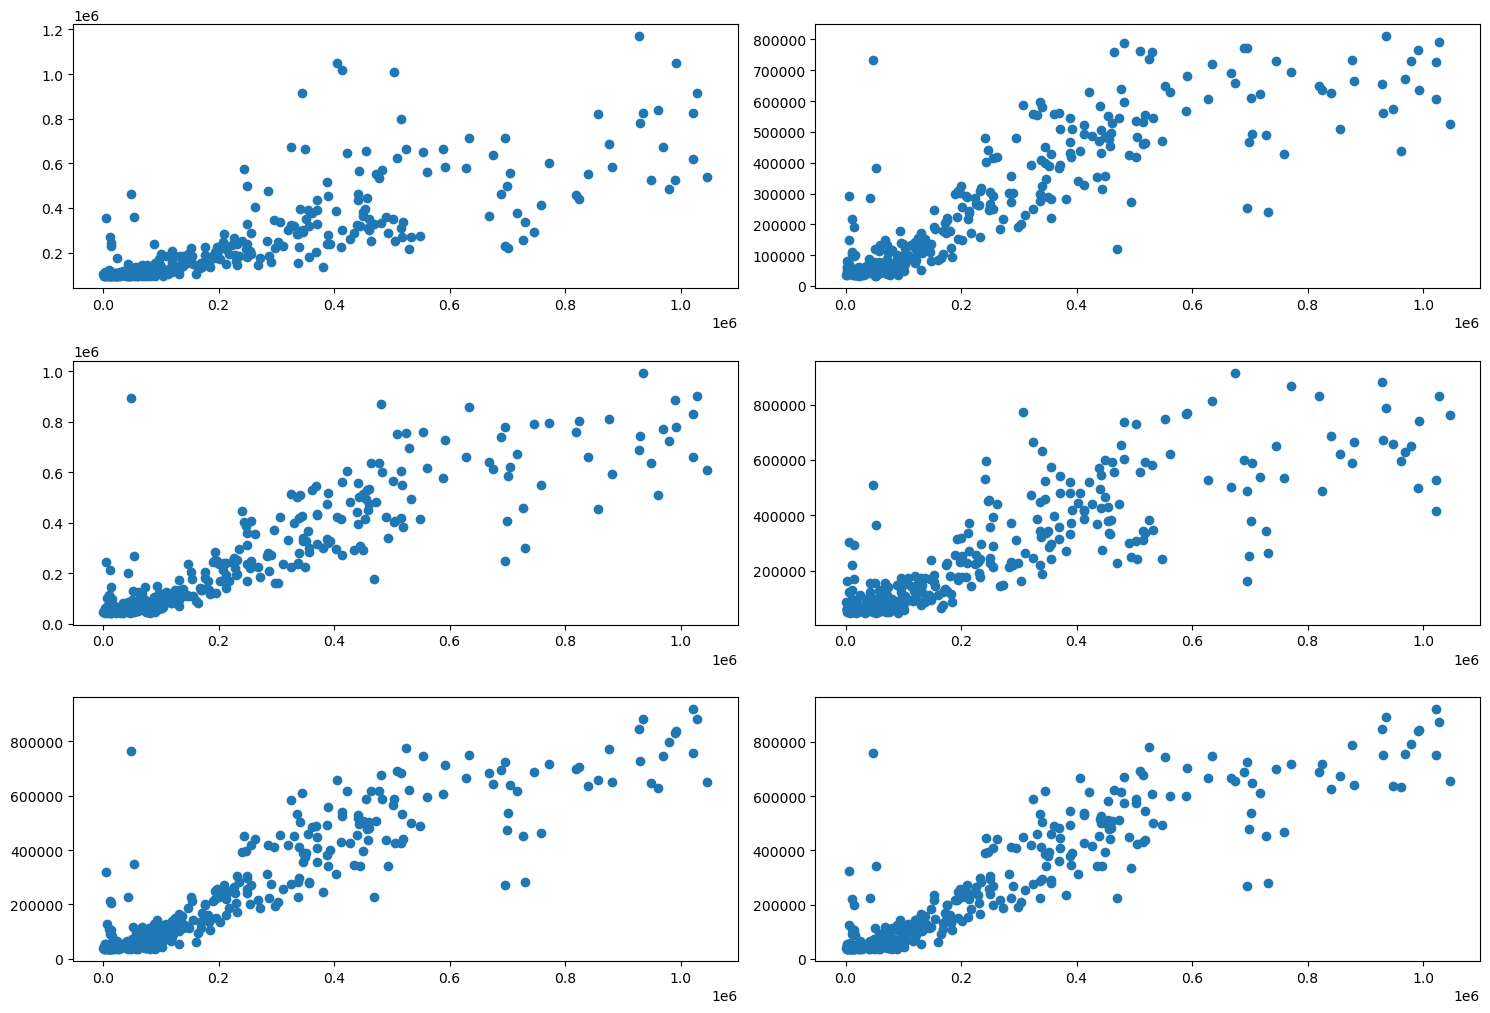

In [100]:
# Assign predictors
X = df[[
    'Aces',
    'BreakPointsFaced',
    'BreakPointsOpportunities',
    'DoubleFaults',
    'ReturnGamesPlayed',
    'ServiceGamesPlayed'
]]

# Assign outcome
y = df[['Winnings']]

# Instantiate LinearRegression
lm = LinearRegression()

# Check train_score, test_score, and scatter plot for each chosen feature
plt.figure(figsize=(15,30))
for idx, col in enumerate(X): 
    feature = df[[col]]
    x_train, x_test, y_train, y_test = train_test_split(feature, y, train_size=0.8, test_size=0.2, random_state=66)
    model = lm.fit(x_train, y_train)
    y_predict = model.predict(x_test)
    
    train_score = lm.score(x_train, y_train)
    test_score = lm.score(x_test, y_test)
    
    print(f"""
    Train Score of {col}: {train_score:.4f}
    Test Score of {col}: {test_score:.4f}
    """)
    print("-"*60)

    plt.subplot(9, 2, idx+1)
    plt.scatter(y_test, y_predict)
plt.tight_layout()
plt.show()
plt.close()

<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>Based on 'test_score', the best combination of two features are (in descending order):</li>
    <ol>
        <li>'BreakPointsFaced' and 'ServiceGamesPlayed'</li>
        <li>'BreakPointsFaced' and 'ReturnGamesPlayed'</li>
        <li>'ReturnGamesPlayed' and 'ServiceGamesPlayed'</li>
    </ol>
</ul>
</div>

In [101]:
# R² values of combination of two best features
for combo in itertools.combinations(X, 2):
    feature = df[list(combo)]
    x_train, x_test, y_train, y_test = train_test_split(feature, y, train_size=0.8, test_size=0.2, random_state=66)
    model = lm.fit(x_train, y_train)
    y_predict = model.predict(x_test)

    train_score = lm.score(x_train, y_train)
    test_score = lm.score(x_test, y_test)

    print(f"""
    Feature: {combo}
    Train Score: {train_score:.4f}
    Test Score: {test_score:.4f}
    """)


    Feature: ('Aces', 'BreakPointsFaced')
    Train Score: 0.8138
    Test Score: 0.7949
    

    Feature: ('Aces', 'BreakPointsOpportunities')
    Train Score: 0.8358
    Test Score: 0.8199
    

    Feature: ('Aces', 'DoubleFaults')
    Train Score: 0.7636
    Test Score: 0.7449
    

    Feature: ('Aces', 'ReturnGamesPlayed')
    Train Score: 0.8337
    Test Score: 0.8310
    

    Feature: ('Aces', 'ServiceGamesPlayed')
    Train Score: 0.8341
    Test Score: 0.8322
    

    Feature: ('BreakPointsFaced', 'BreakPointsOpportunities')
    Train Score: 0.8127
    Test Score: 0.8031
    

    Feature: ('BreakPointsFaced', 'DoubleFaults')
    Train Score: 0.7859
    Test Score: 0.7750
    

    Feature: ('BreakPointsFaced', 'ReturnGamesPlayed')
    Train Score: 0.8347
    Test Score: 0.8366
    

    Feature: ('BreakPointsFaced', 'ServiceGamesPlayed')
    Train Score: 0.8350
    Test Score: 0.8371
    

    Feature: ('BreakPointsOpportunities', 'DoubleFaults')
    Train Score: 0.8220


<div style="background-color: #e6f7ff; padding: 10px;"> 
<ul>
    <li>R² value for all six best features combined produced an equal R² value of test set with 'BreakPointsFaced' and 'ServiceGamesPlayed' combined.</li>
    <li>This suggests that extra features do not improve prediction and may be unnecessary.</li>
    <li>The simpler two-features model is preferred for interpretability and avoid overfitting.</li>
</ul>
</div>

In [102]:
# R² for combination of all best features
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=66)
model = lm.fit(x_train, y_train)
y_predict = model.predict(x_test)

train_score = lm.score(x_train, y_train)
test_score = lm.score(x_test, y_test)

print(f"""
Train Score: {train_score:.4f}
Test Score: {test_score:.4f}
""")


Train Score: 0.8420
Test Score: 0.8369



## FINDINGS

<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>Two-features model between 'BreakPointsFaced' and 'ServiceGamesPlayed' produced R² value that is almost equal to a model that has all the features.</li>
    <li>Because of that, it is preferred as other features do not improved prediction.</li>
    <li>'BreakPointsFaced' and 'ServiceGamesPlayed' are the two most important features in predicting 'Winnings'.</li>
</ul>
</div>